In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

First logarithmic transformation was applied to reduce skewness in cost and weight features, then StandardScaler normalised features and then Kmeans grouped similar clusters based on transformed features


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [3]:
df = pd.read_csv("Train.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
print("Missing Values:\n")
df.isnull().sum()

Missing Values:



,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


In [7]:
df = df.dropna()

In [8]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [9]:
cluster_df = df[['Cost_of_the_Product','Weight_in_gms']]
cluster_df.head()

,Cost_of_the_Product,Weight_in_gms
0,177,1233
1,216,3088
2,183,3374
3,176,1177
4,184,2484


In [11]:
cluster_df['Cost_log'] = np.log1p(cluster_df['Cost_of_the_Product'])
cluster_df['Weight_log'] = np.log1p(cluster_df['Weight_in_gms'])

cluster_df[['Cost_log','Weight_log']].head()

,Cost_log,Weight_log
0,5.181784,7.118016
1,5.379897,8.035603
2,5.214936,8.124151
3,5.176150,7.071573
4,5.220356,7.818028


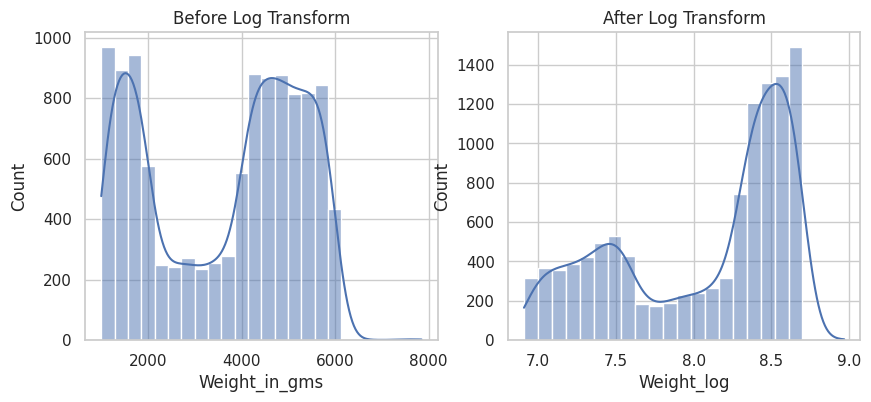

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(cluster_df['Weight_in_gms'], kde=True)
plt.title("Before Log Transform")
plt.subplot(1,2,2)
sns.histplot(cluster_df['Weight_log'], kde=True)
plt.title("After Log Transform")
plt.show()

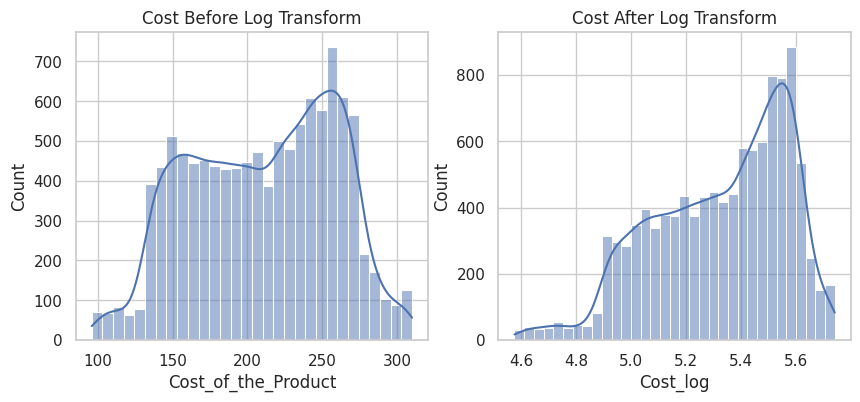

In [13]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(cluster_df['Cost_of_the_Product'], kde=True)
plt.title("Cost Before Log Transform")
plt.subplot(1,2,2)
sns.histplot(cluster_df['Cost_log'], kde=True)
plt.title("Cost After Log Transform")
plt.show()

In [14]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    cluster_df[['Cost_log','Weight_log']]
)
scaled_df = pd.DataFrame(
    scaled_features,
    columns=['Cost_scaled','Weight_scaled']
)
scaled_df.head()

,Cost_scaled,Weight_scaled
0,-0.588065,-1.699395
1,0.227372,-0.051426
2,-0.451611,0.107604
3,-0.611254,-1.782805
4,-0.429302,-0.442186


In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_df)
cluster_df['Cluster_Label'] = cluster_labels
cluster_df.head()

,Cost_of_the_Product,Weight_in_gms,Cost_log,Weight_log,Cluster_Label
0,177,1233,5.181784,7.118016,1
1,216,3088,5.379897,8.035603,0
2,183,3374,5.214936,8.124151,2
3,176,1177,5.176150,7.071573,1
4,184,2484,5.220356,7.818028,2


In [16]:
cluster_df['Cluster_Label'].value_counts()

,count
Cluster_Label,
0,5354
2,3098
1,2547


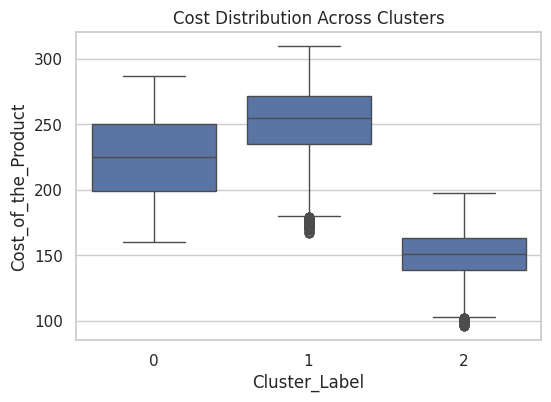

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Cluster_Label',
    y='Cost_of_the_Product',
    data=cluster_df
)
plt.title("Cost Distribution Across Clusters")
plt.show()

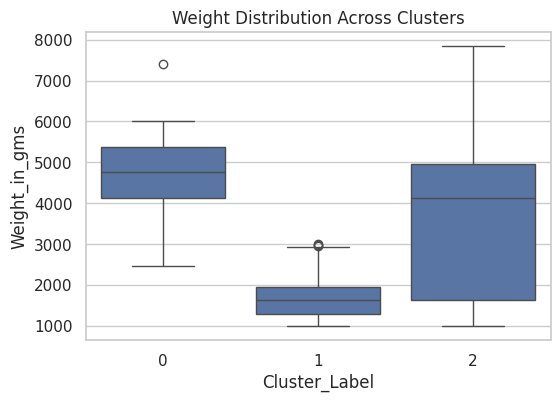

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='Cluster_Label',
    y='Weight_in_gms',
    data=cluster_df
)
plt.title("Weight Distribution Across Clusters")
plt.show()